In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, ConcatDataset
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
import os
import random
import copy
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score, confusion_matrix, accuracy_score
from sklearn.model_selection import KFold
from sklearn.manifold import TSNE
from functools import reduce
from scipy.interpolate import interp1d

In [2]:
# Set random seeds
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

In [3]:
# set device for torch 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Loading the dataset

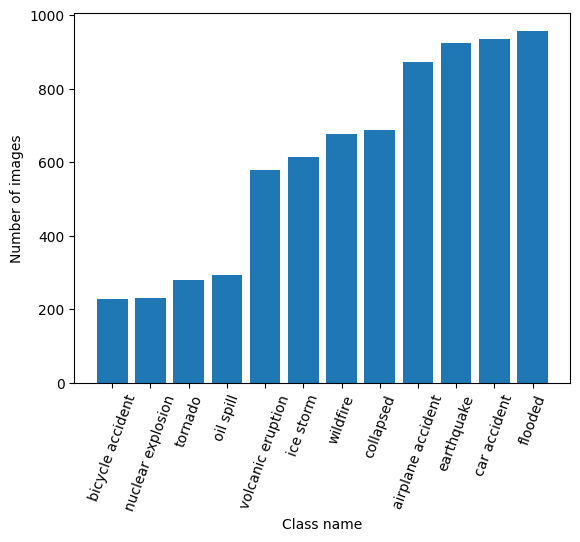

In [4]:
root_dir = 'Incidents-subset'

classes = os.listdir(root_dir)
cat_and_len = {classname:len(os.listdir(os.path.join(root_dir, classname))) for classname in classes}
cat_and_len = dict(sorted(cat_and_len.items(), key=lambda item: item[1]))

plt.bar(range(len(cat_and_len.values())), cat_and_len.values())
plt.xticks(range(len(cat_and_len.keys())), cat_and_len.keys(), rotation=70)
plt.xlabel("Class name")
plt.ylabel("Number of images")
plt.show()

In [5]:
resize_size = 352

# load dataset
dataset = datasets.ImageFolder(root_dir, transform=transforms.Resize((resize_size, resize_size)))

In [6]:
print(f"Length of the dataset: {len(dataset)}")

Length of the dataset: 7280


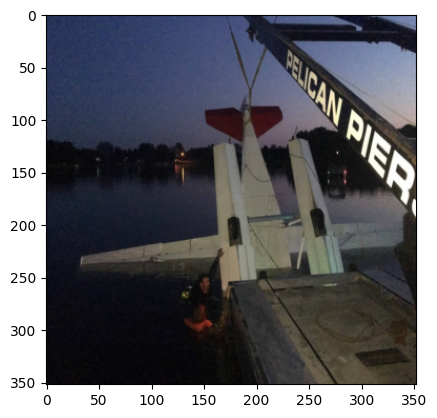

In [7]:
plt.imshow(dataset[99][0])

In [8]:
# define transforms
# apply data augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(resize_size, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.ToTensor()
])

In [9]:
class CustomDataset(Dataset):
    def __init__(self, img_data, transform=None):
        self.img_data = img_data
        self.transform = transform

    def __len__(self):
        return len(self.img_data)

    def __getitem__(self, idx):
        img, label = self.img_data[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Model definitions and training

In [10]:
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=8):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction, in_channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

In [11]:
class SEMobileNetV2(nn.Module):
    def __init__(self, num_classes=12, pretrained=False):
        super(SEMobileNetV2, self).__init__()
        
        if pretrained:
            mobilenet_v2 = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        else:
            mobilenet_v2 = models.mobilenet_v2(weights=None)
        
        self.features = mobilenet_v2.features

        # Adding SE blocks to depthwise conv layers
        for _, inv_module in self.features.named_children(): 
            if isinstance(inv_module, torchvision.models.mobilenetv2.InvertedResidual):
                for _, module in inv_module._modules.items():
                    if isinstance(module, nn.Sequential):
                        for idx, (_, layer) in enumerate(module._modules.items()):
                            if isinstance(layer, torchvision.ops.misc.Conv2dNormActivation) and not \
                               isinstance(module[idx+1], torchvision.ops.misc.Conv2dNormActivation):
                                module.insert(idx+1, SEBlock(layer.out_channels))
                                break
                            if isinstance(layer, nn.Conv2d):
                                module.insert(idx+1, SEBlock(layer.out_channels))
                                break

        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(mobilenet_v2.classifier[1].in_features, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.mean([2, 3])
        x = self.classifier(x)
        return x

In [12]:
class SEResNet50(nn.Module):
    def __init__(self, num_classes=12, pretrained=False):
        super(SEResNet50, self).__init__()
        if pretrained:
            resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        else:
            resnet50 = models.resnet50(weights=None)
            
        self.conv1 = resnet50.conv1
        self.bn1 = resnet50.bn1
        self.relu = resnet50.relu
        self.maxpool = resnet50.maxpool
        self.layer1 = self._add_se_blocks(resnet50.layer1)
        self.layer2 = self._add_se_blocks(resnet50.layer2)
        self.layer3 = self._add_se_blocks(resnet50.layer3)
        self.layer4 = self._add_se_blocks(resnet50.layer4)
        self.avgpool = resnet50.avgpool
        self.fc = nn.Linear(resnet50.fc.in_features, num_classes)

    def _add_se_blocks(self, layer):
        for bottleneck in layer.children():
            in_channels = bottleneck.conv3.out_channels
            se_block = SEBlock(in_channels)
            bottleneck.add_module("se_block", se_block)
        return layer

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [13]:
def load_model(model_name, num_classes, pretrained=False):
    if model_name=='resnet50':
        if pretrained:
            model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        else:
            model = models.resnet50(weights=None)
        num_features = model.fc.in_features
        model.fc = nn.Linear(num_features, num_classes)
    elif model_name=='mobilenetv2':
        if pretrained:
            model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        else:
            model = models.mobilenet_v2(weights=None)
        num_features = model.classifier[1].in_features
        model.classifier[1] = torch.nn.Linear(num_features, num_classes)
    elif model_name=='resnet50_attention':
        model = SEResNet50(num_classes, pretrained)
    elif model_name=='mobilenetv2_attention':
        model = SEMobileNetV2(num_classes, pretrained)
    return model

In [14]:
# function that shows test accuracy of the model for each class and then combined
def show_accuracies(classes, testloader, model):
    # prepare to count predictions for each class
    correct_pred = {classname: 0 for classname in classes}
    total_pred = {classname: 0 for classname in classes}

    # again no gradients needed
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predictions = torch.max(outputs, 1)
            # collect the correct predictions for each class
            for label, prediction in zip(labels, predictions):
                if label == prediction:
                    correct_pred[classes[label]] += 1
                total_pred[classes[label]] += 1

    accuracy_list = []
    # print accuracy for each class
    for classname, correct_count in correct_pred.items():
        accuracy = 100 * float(correct_count) / total_pred[classname]
        accuracy_list.append(accuracy)
        print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

    # print total accuracy
    print(f'Accuracy on the test set: {round(np.mean(accuracy_list),1)}%')
    return round(np.mean(accuracy_list),1)

In [15]:
def train_model(model, num_epochs, train_loader, test_loader, criterion, optimizer):
    train_losses = []
    train_accuracies = []
    test_accuracies = []

    for epoch in tqdm(range(num_epochs)):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
                
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_accuracy = correct / total
        train_loss = running_loss / len(train_loader)
        
        # Append the values to the lists
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        
        model.eval()
        accuracy = show_accuracies(classes, test_loader, model)
        test_accuracies.append(accuracy)

    weights = copy.deepcopy(model.state_dict())
    
    return weights, train_losses, train_accuracies, test_accuracies

In [16]:
def oversample_classwise(dataset, target_size):
    class_data = {}
    
    # Group samples by class
    for img, label in dataset:
        if label not in class_data:
            class_data[label] = []
        class_data[label].append((img, label))
    
    # Oversample each class
    for label, data in class_data.items():
        class_data[label] = oversample_dataset(data, target_size)
    
    # Combine the oversampled classes
    oversampled_data = []
    for _, data in class_data.items():
        oversampled_data.extend(data)
    
    return oversampled_data

def oversample_dataset(dataset, target_size):
    samples_needed = target_size - len(dataset)
    new_samples = []
    for _ in range(samples_needed):
        index = random.randint(0, len(dataset) - 1)
        new_samples.append(dataset[index])
    return dataset + new_samples

In [17]:
def k_fold_cross_validation(model_name, dataset, k=5, num_epochs=10, batch_size=32, oversample=False, oversample_class_size=1024, pretrained=False):
    if not os.path.exists('results'):
        os.makedir('results')
        
    if oversample:
        oversample_status = '_oversampled'
    else:
        oversample_status = ''
    
    if pretrained:
        pretrained_status = '_pretrained'
    else:
        pretrained_status = ''
        
    if not os.path.exists(os.path.join('results', model_name.split('_')[0], f'{model_name}{oversample_status}{pretrained_status}')):
        os.makedirs(os.path.join('results', model_name.split('_')[0], f'{model_name}{oversample_status}{pretrained_status}'))
        
        # Create the subdirectories
        for i in range(1, k+1):
            fold_name = f"fold_{i}"
            os.makedirs(os.path.join('results', model_name.split('_')[0], f'{model_name}{oversample_status}{pretrained_status}', fold_name))

    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    
    # K-Fold cross validation
    kfold = KFold(n_splits=k, shuffle=True)
        
    for fold, (train_indices, test_indices) in enumerate(kfold.split(dataset)):
        print(f'Fold {fold + 1}')
        
        current_dir = os.path.join('results', model_name.split('_')[0], f'{model_name}{oversample_status}{pretrained_status}', f'fold_{fold + 1}')

        # Initialize the model
        model = load_model(model_name, len(classes), pretrained).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

        # Extract train and test subsets
        train_subset = [dataset[i] for i in train_indices]
        test_subset = [dataset[i] for i in test_indices]

        # Perform oversampling and data augmentation for the train subset
        if oversample:
            train_subset = oversample_classwise(train_subset, oversample_class_size)

        train_subset = CustomDataset(train_subset, transform=train_transform)
        test_subset = CustomDataset(test_subset, transform=test_transform)

        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True) 
        test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

        # Train the model and store its best weights
        weights, train_losses, train_accuracies, test_accuracies = train_model(model, num_epochs, train_loader, test_loader, criterion, optimizer)
        
        # Save train indices to file
        np.save(os.path.join(current_dir, "train_indices.npy"), train_indices)
        # Save test indices to file
        np.save(os.path.join(current_dir, "test_indices.npy"), test_indices)
        
        np.save(os.path.join(current_dir, "train_losses.npy"), train_losses)
        np.save(os.path.join(current_dir, "train_accuracies.npy"), train_accuracies)
        np.save(os.path.join(current_dir, "test_accuracies.npy"), test_accuracies)
        torch.save(weights, os.path.join(current_dir, f'weights.pt'))

    print('Finished!')

In [18]:
# set parameters
model_name = 'mobilenetv2_attention'
oversample = True
oversample_class_size = 1024
pretrained = True

num_folds = 5
num_epochs = 25

k_fold_cross_validation(model_name, dataset, k=num_folds, num_epochs=num_epochs, batch_size=32, oversample=oversample, oversample_class_size=oversample_class_size, pretrained=pretrained)

Fold 1


C:\Users\raulv\Desktop\2A\2A-env\lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  4%|███▎                                                                              | 1/25 [02:16<54:27, 136.13s/it]

Accuracy for class: airplane accident is 79.8 %
Accuracy for class: bicycle accident is 93.0 %
Accuracy for class: car accident is 73.5 %
Accuracy for class: collapsed is 52.5 %
Accuracy for class: earthquake is 74.5 %
Accuracy for class: flooded is 88.3 %
Accuracy for class: ice storm is 92.2 %
Accuracy for class: nuclear explosion is 89.1 %
Accuracy for class: oil spill is 44.4 %
Accuracy for class: tornado is 87.2 %
Accuracy for class: volcanic eruption is 85.0 %
Accuracy for class: wildfire is 81.1 %
Accuracy on the test set: 78.4%


  8%|██████▌                                                                           | 2/25 [04:24<50:29, 131.71s/it]

Accuracy for class: airplane accident is 61.7 %
Accuracy for class: bicycle accident is 81.4 %
Accuracy for class: car accident is 75.0 %
Accuracy for class: collapsed is 50.4 %
Accuracy for class: earthquake is 89.9 %
Accuracy for class: flooded is 76.1 %
Accuracy for class: ice storm is 80.6 %
Accuracy for class: nuclear explosion is 92.7 %
Accuracy for class: oil spill is 59.3 %
Accuracy for class: tornado is 93.6 %
Accuracy for class: volcanic eruption is 66.0 %
Accuracy for class: wildfire is 89.0 %
Accuracy on the test set: 76.3%


...

Accuracy for class: airplane accident is 83.9 %
Accuracy for class: bicycle accident is 74.5 %
Accuracy for class: car accident is 82.8 %
Accuracy for class: collapsed is 62.1 %
Accuracy for class: earthquake is 84.2 %
Accuracy for class: flooded is 84.0 %
Accuracy for class: ice storm is 84.6 %
Accuracy for class: nuclear explosion is 67.3 %
Accuracy for class: oil spill is 63.9 %
Accuracy for class: tornado is 95.0 %
Accuracy for class: volcanic eruption is 83.9 %
Accuracy for class: wildfire is 91.5 %
Accuracy on the test set: 79.8%


 96%|█████████████████████████████████████████████████████████████████████████████▊   | 24/25 [50:10<02:05, 125.27s/it]

Accuracy for class: airplane accident is 65.2 %
Accuracy for class: bicycle accident is 80.9 %
Accuracy for class: car accident is 92.5 %
Accuracy for class: collapsed is 63.6 %
Accuracy for class: earthquake is 77.9 %
Accuracy for class: flooded is 87.4 %
Accuracy for class: ice storm is 85.4 %
Accuracy for class: nuclear explosion is 76.9 %
Accuracy for class: oil spill is 63.9 %
Accuracy for class: tornado is 93.3 %
Accuracy for class: volcanic eruption is 83.1 %
Accuracy for class: wildfire is 87.7 %
Accuracy on the test set: 79.8%


100%|█████████████████████████████████████████████████████████████████████████████████| 25/25 [52:15<00:00, 125.41s/it]

Accuracy for class: airplane accident is 81.9 %
Accuracy for class: bicycle accident is 76.6 %
Accuracy for class: car accident is 85.6 %
Accuracy for class: collapsed is 69.7 %
Accuracy for class: earthquake is 73.0 %
Accuracy for class: flooded is 89.7 %
Accuracy for class: ice storm is 82.3 %
Accuracy for class: nuclear explosion is 65.4 %
Accuracy for class: oil spill is 73.8 %
Accuracy for class: tornado is 86.7 %
Accuracy for class: volcanic eruption is 88.1 %
Accuracy for class: wildfire is 90.0 %
Accuracy on the test set: 80.2%
Finished!


# Evaluation

## Define functions

In [19]:
def plot_results(train_losses, train_accuracies, test_accuracies):
    num_epochs = len(train_losses[0])
    # Calculate the average, best, and worst case for each epoch
    avg_train_losses = np.mean(train_losses, axis=0)
    avg_train_accuracies = np.mean(train_accuracies, axis=0)
    avg_test_accuracies = np.mean(test_accuracies, axis=0)

    best_train_accuracies = np.max(train_accuracies, axis=0)
    best_test_accuracies = np.max(test_accuracies, axis=0)

    worst_train_accuracies = np.min(train_accuracies, axis=0)
    worst_test_accuracies = np.min(test_accuracies, axis=0)

    # Plot loss vs epochs
    plt.figure()
    plt.plot(range(1, num_epochs + 1), avg_train_losses, 'b')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Train loss')

    # Plot train and test accuracy vs epochs
    plt.figure()
    epochs_range = range(1, num_epochs + 1)
    
    plt.plot(epochs_range, avg_train_accuracies, 'b', label='Average Train Accuracy')
    plt.plot(epochs_range, avg_test_accuracies, 'r', label='Average Test Accuracy')

    plt.fill_between(epochs_range, worst_train_accuracies, best_train_accuracies, color='b', alpha=0.1)
    plt.fill_between(epochs_range, worst_test_accuracies, best_test_accuracies, color='r', alpha=0.1)

    plt.xlabel('Epochs')
    plt.ylabel('Accuracy [%]')
    plt.legend()
    plt.title('Train and Test Accuracy')

    # Show the plots
    plt.show()

In [20]:
def evaluate_model(model_list, test_loader_list, classes):
    assert len(model_list) == len(test_loader_list), "Number of models and testloaders must be equal."

    num_folds = len(model_list)
    all_average_precisions = []
    all_cms = []
    all_f1s = []
    all_accuracies = []

    all_precisions = []
    all_recalls = []

    for fold in range(num_folds):
        model = model_list[fold].to(device)
        model.eval()
        testloader = test_loader_list[fold]

        all_labels = []
        all_predictions = []
        all_probabilities = []

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                probabilities = torch.softmax(outputs, dim=1)
                predictions = torch.argmax(probabilities, dim=1)

                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predictions.cpu().numpy())
                all_probabilities.extend(probabilities.cpu().numpy())

        all_labels = np.array(all_labels)
        all_predictions = np.array(all_predictions)
        all_probabilities = np.array(all_probabilities)

        # Precision-recall curve and AP
        precision = dict()
        recall = dict()
        average_precision = dict()
        for i in range(len(classes)):
            precision[i], recall[i], _ = precision_recall_curve(all_labels == i, all_probabilities[:, i])
            average_precision[i] = average_precision_score(all_labels == i, all_probabilities[:, i])

        all_precisions.append(precision)
        all_recalls.append(recall)
        all_average_precisions.append(average_precision)

        # Confusion matrix
        cm = confusion_matrix(all_labels, all_predictions)
        all_cms.append(cm)

        # F1 score
        f1 = f1_score(all_labels, all_predictions, average='weighted')
        all_f1s.append(f1)

        # Accuracy
        accuracy = accuracy_score(all_labels, all_predictions)
        all_accuracies.append(accuracy)

    def pad_arrays(arrays):
        max_length = max([len(a) for a in arrays])
        padded_arrays = []
        for a in arrays:
            padded_array = np.pad(a, (0, max_length - len(a)), 'edge')
            padded_arrays.append(padded_array)
        return padded_arrays

    # Average results over all folds
    avg_average_precisions = {i: np.mean([ap[i] for ap in all_average_precisions]) for i in range(len(classes))}
    avg_cm = np.mean(all_cms, axis=0)
    avg_f1 = np.mean(all_f1s)
    avg_accuracy = np.mean(all_accuracies)

    # Average precision and recall for the plot
    avg_precisions = {i: np.mean(pad_arrays([p[i] for p in all_precisions]), axis=0) for i in range(len(classes))}
    avg_recalls = {i: np.mean(pad_arrays([r[i] for r in all_recalls]), axis=0) for i in range(len(classes))}

    # Plotting and printing results
    plt.figure()
    for i in range(len(classes)):
        plt.plot(avg_recalls[i], avg_precisions[i], label=f'{classes[i]} (AP = {avg_average_precisions[i]:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall curve')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.show()

    # Confusion matrix plot
    normalized_cm = avg_cm.astype('float') / avg_cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 12))  # Set the figure size
    plt.imshow(normalized_cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Normalized Confusion Matrix')
    cbar = plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')

    # Add numbers to the confusion matrix
    thresh = normalized_cm.max() / 2.
    for i in range(normalized_cm.shape[0]):
        for j in range(normalized_cm.shape[1]):
            plt.text(j, i, format(normalized_cm[i, j], '.2f'),
                     horizontalalignment="center",
                     color="white" if normalized_cm[i, j] > thresh else "black")

    plt.show()

    print(f'F1 score: {avg_f1:.4f}')
    print(f'Accuracy: {avg_accuracy:.4f}')

    return avg_precisions, avg_recalls, avg_average_precisions, avg_cm, avg_f1, avg_accuracy

In [21]:
def tsne_map(model, dataloader, classes):
    model.eval()  # Set the model to evaluation mode
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Extract features from the model
    features = []
    labels = []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            features.extend(outputs.cpu().numpy())
            labels.extend(targets.cpu().numpy())

    # Convert lists to NumPy arrays
    features = np.array(features)
    labels = np.array(labels)

    # Perform T-SNE
    features_embedded = TSNE(n_components=2).fit_transform(features)

    # Plot the T-SNE map
    fig, ax = plt.subplots()
    for i, class_name in enumerate(classes):
        indices = np.where(labels == i)
        ax.scatter(features_embedded[indices, 0], features_embedded[indices, 1], label=class_name)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    ax.set_xlabel('t-SNE dimension 1')
    ax.set_ylabel('t-SNE dimension 2')
    plt.title('T-SNE Plot')
    plt.show()

In [22]:
def show_saliency_map(model, dataloader):
    # Function to get a random image and its label from the dataloader
    def get_random_image_and_label(dataloader):
        # Get the number of batches in the dataloader
        num_batches = len(dataloader)

        # Select a random batch index
        random_batch_idx = random.randint(0, num_batches - 1)

        # Get the random batch
        for i, (images, labels) in enumerate(dataloader):
            if i == random_batch_idx:
                random_images = images
                random_labels = labels
                break

        # Get the number of images in the batch
        batch_size = len(random_images)

        # Select a random image index within the batch
        random_image_idx = random.randint(0, batch_size - 1)

        return random_images[random_image_idx].unsqueeze(0), random_labels[random_image_idx].unsqueeze(0)

    # Get a random image and its label from the dataloader
    image, label = get_random_image_and_label(dataloader)

    # Set the model to evaluation mode and move it to the appropriate device
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    image = image.to(device)
    label = label.to(device)

    # Get the gradients with respect to the input image
    image.requires_grad = True
    output = model(image)
    model.zero_grad()
    output[0, label].backward()

    # Get the absolute gradients and normalize them
    gradients = image.grad.abs().detach().cpu().numpy()
    gradients = gradients - gradients.min()
    gradients = gradients / gradients.max()

    # Visualize the original image
    image_np = image.detach().cpu().numpy()
    image_np = np.transpose(image_np[0], (1, 2, 0))
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image_np)
    plt.axis('off')
    plt.title('Original Image')

    # Visualize the saliency map in red color
    plt.subplot(1, 2, 2)
    saliency_map = np.transpose(gradients[0]*10, (1, 2, 0))
    saliency_map = np.mean(saliency_map, axis=2)  # Average the gradients across channels
    saliency_map = plt.get_cmap('plasma')(saliency_map)  # Apply the 'jet' colormap
    plt.imshow(saliency_map)
    plt.axis('off')
    plt.title('Saliency Map')

    plt.show()

In [23]:
def plot_all(model_name, oversample, pretrained, num_folds):
    all_train_losses = []
    all_train_accuracies = []
    all_test_accuracies = []

    if oversample:
        oversample_status = '_oversampled'
    else:
        oversample_status = ''

    if pretrained:
        pretrained_status = '_pretrained'
    else:
        pretrained_status = ''

    for i in range(1, num_folds+1):
        fold_name = f"fold_{i}"
        all_train_losses.append(np.load(os.path.join('results', model_name.split('_')[0], f'{model_name}{oversample_status}{pretrained_status}', fold_name, 'train_losses.npy')))
        all_train_accuracies.append(np.load(os.path.join('results', model_name.split('_')[0], f'{model_name}{oversample_status}{pretrained_status}', fold_name, 'train_accuracies.npy'))*100)
        all_test_accuracies.append(np.load(os.path.join('results', model_name.split('_')[0], f'{model_name}{oversample_status}{pretrained_status}', fold_name, 'test_accuracies.npy')))

    model_list = []
    test_loader_list = []

    for fold in range(1, num_folds+1):
        sampler = torch.utils.data.SubsetRandomSampler(np.load(os.path.join('results', model_name.split('_')[0], f'{model_name}{oversample_status}{pretrained_status}', f'fold_{fold}', 'test_indices.npy')))
        subset = CustomDataset(dataset, transform=test_transform)
        test_loader = DataLoader(subset, batch_size=32, sampler=sampler)

        model = load_model(model_name, len(classes)).to('cuda')
        model.load_state_dict(torch.load(os.path.join('results', model_name.split('_')[0], f'{model_name}{oversample_status}{pretrained_status}', f'fold_{fold}', 'weights.pt')))

        model_list.append(model)
        test_loader_list.append(test_loader)

    plot_results(all_train_losses, all_train_accuracies, all_test_accuracies)
    avg_precisions, avg_recalls, avg_average_precisions, avg_cm, avg_f1, avg_accuracy = evaluate_model(model_list, test_loader_list, classes)
    tsne_map(model_list[0], test_loader_list[0], classes)

## Generate plots

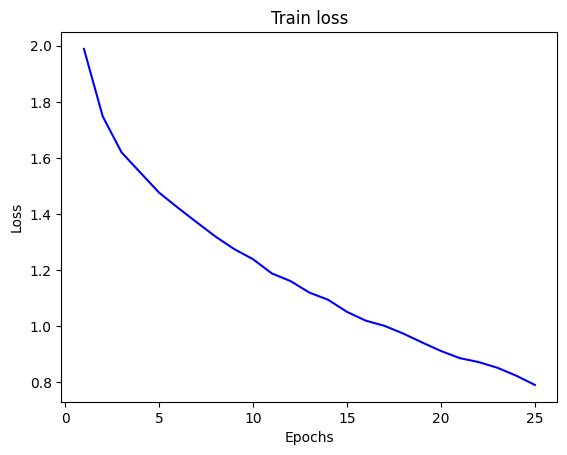

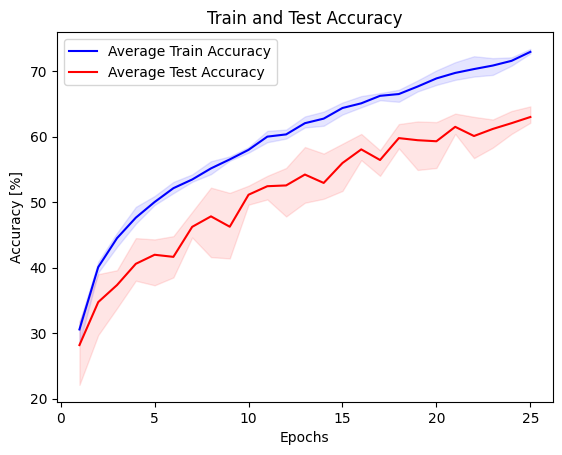

C:\Users\raulv\Desktop\2A\2A-env\lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


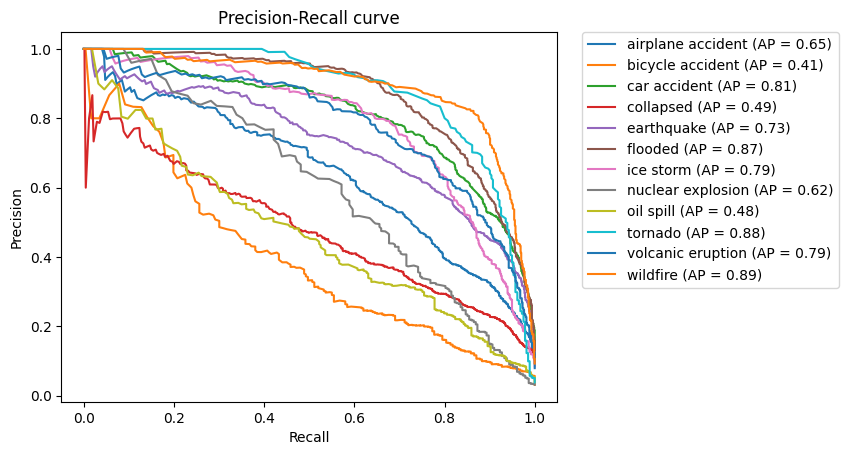

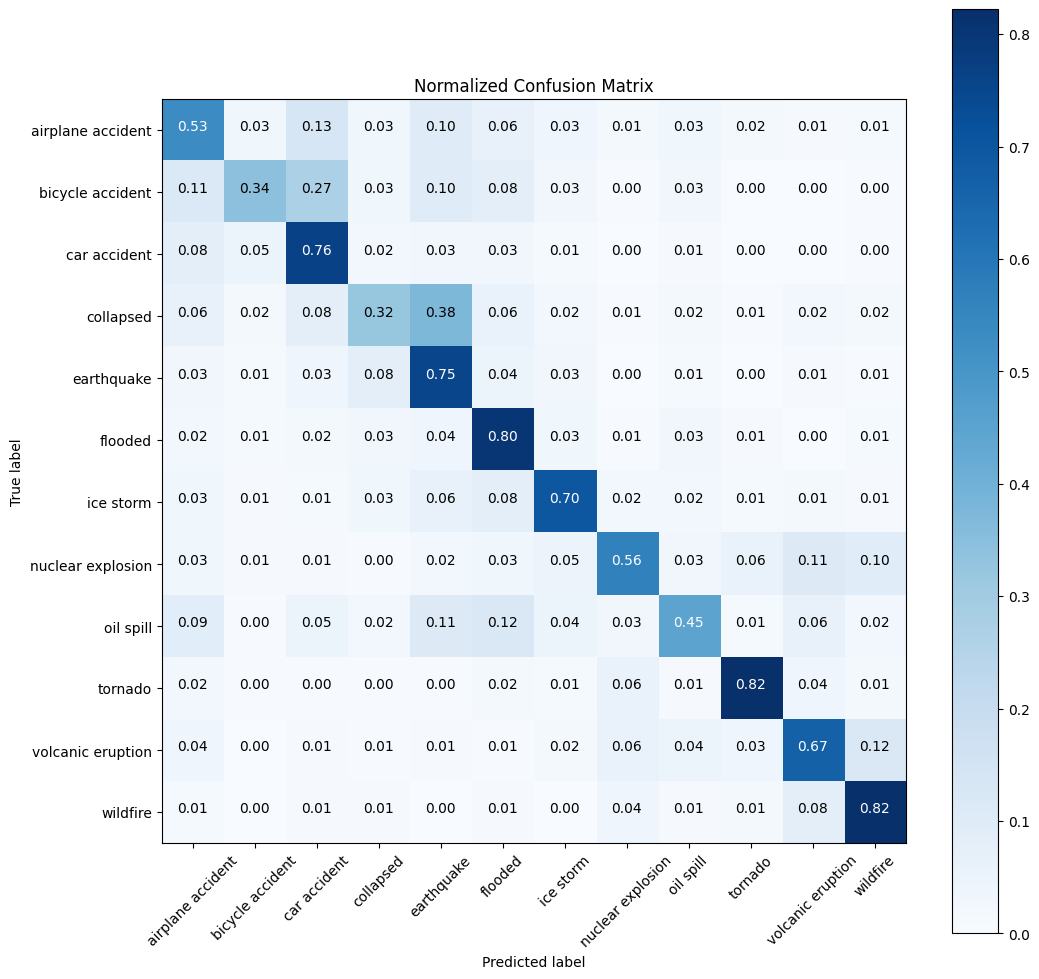

F1 score: 0.6487
Accuracy: 0.6606


C:\Users\raulv\Desktop\2A\2A-env\lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


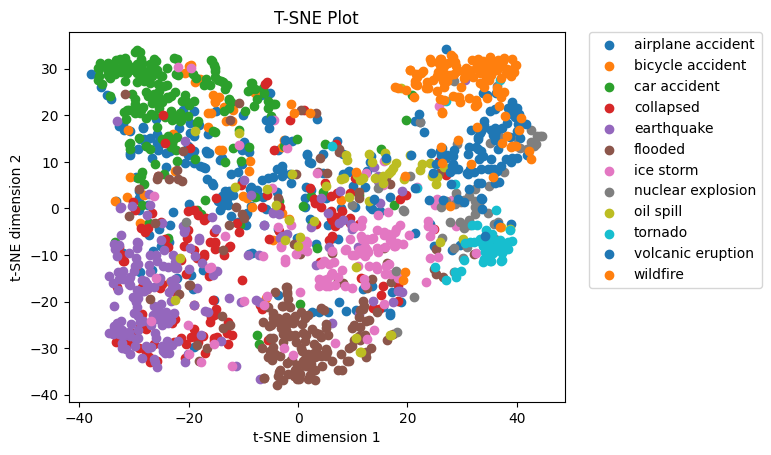

In [216]:
plot_all(model_name='mobilenetv2', oversample=False, pretrained=False, num_folds=5)

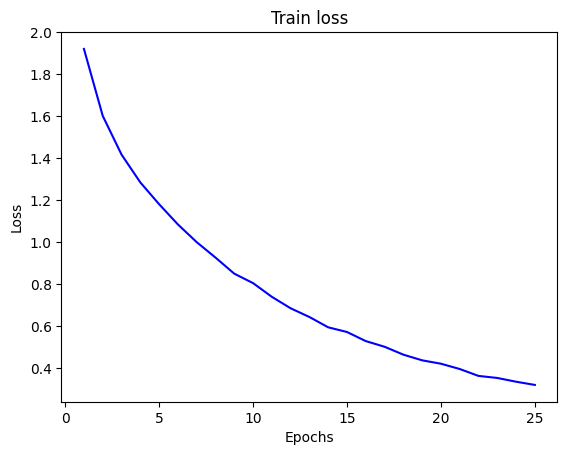

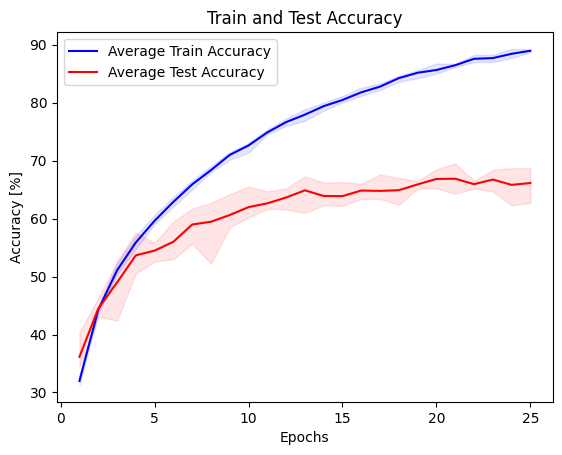

C:\Users\raulv\Desktop\2A\2A-env\lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


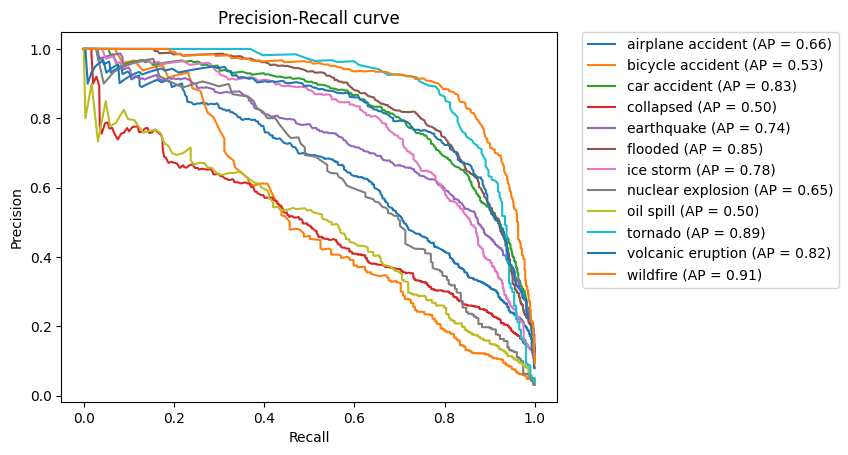

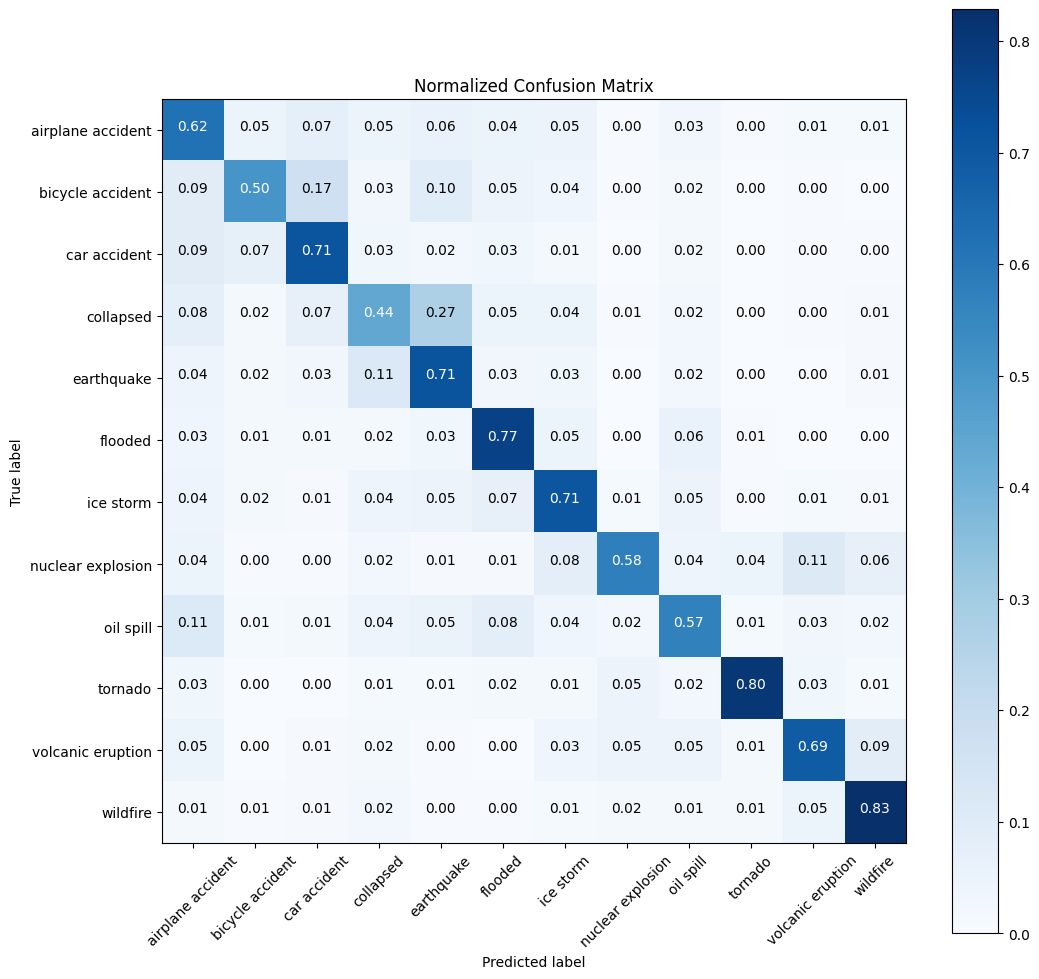

F1 score: 0.6784
Accuracy: 0.6783


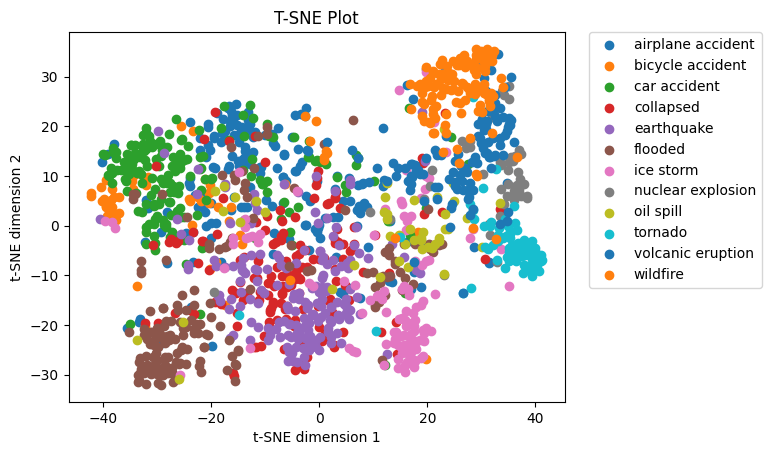

In [215]:
plot_all(model_name='mobilenetv2', oversample=True, pretrained=False, num_folds=5)

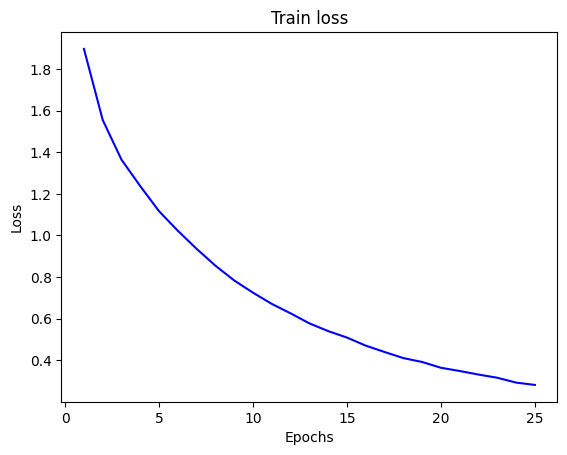

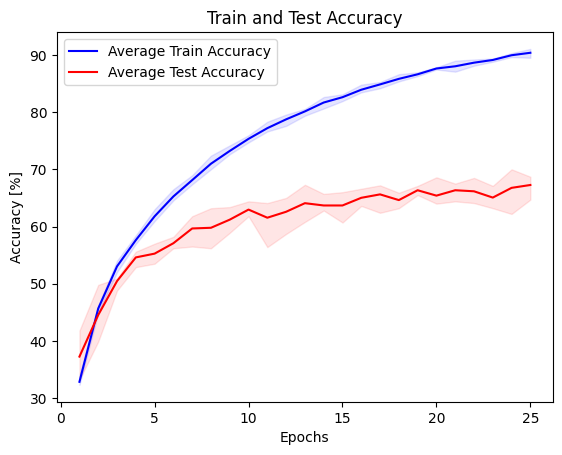

C:\Users\raulv\Desktop\2A\2A-env\lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


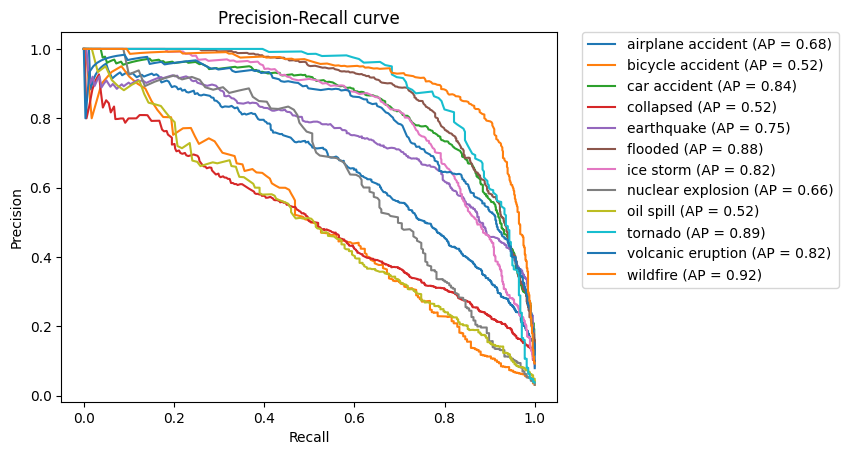

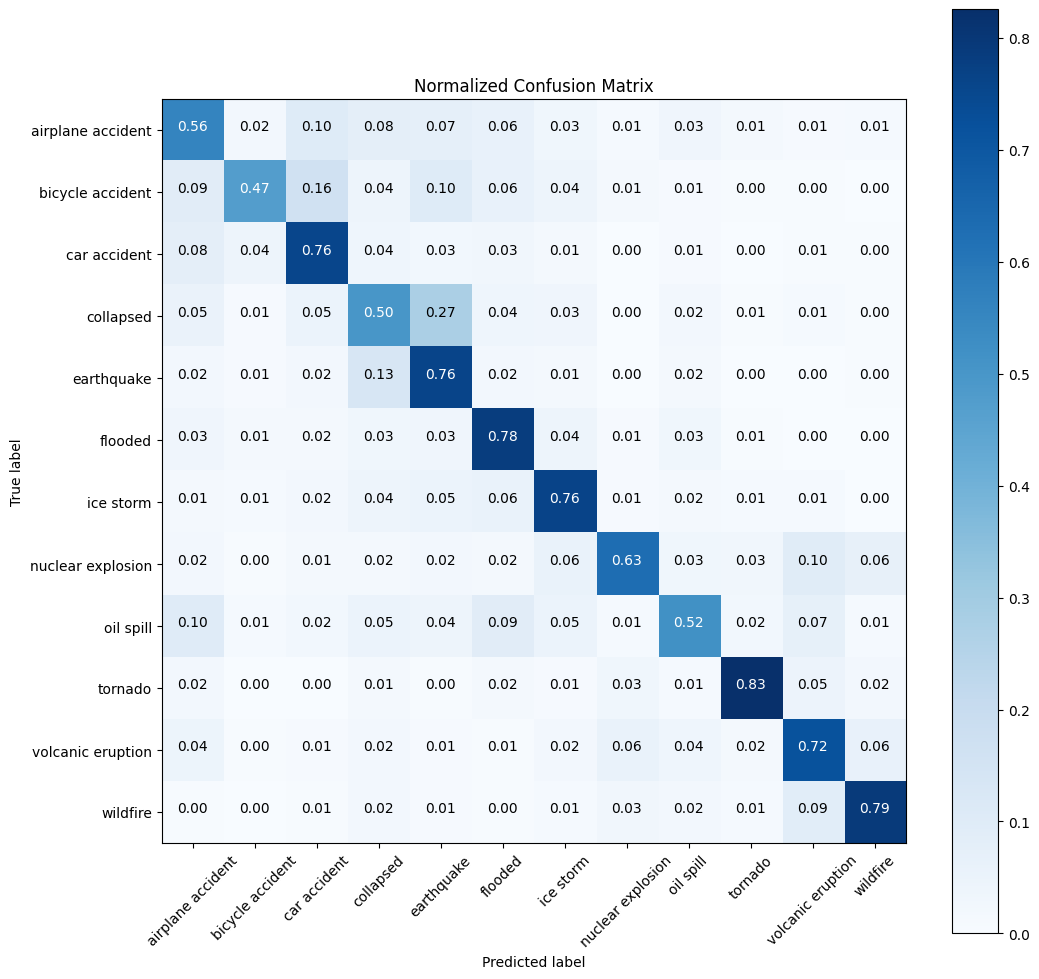

F1 score: 0.6915
Accuracy: 0.6933


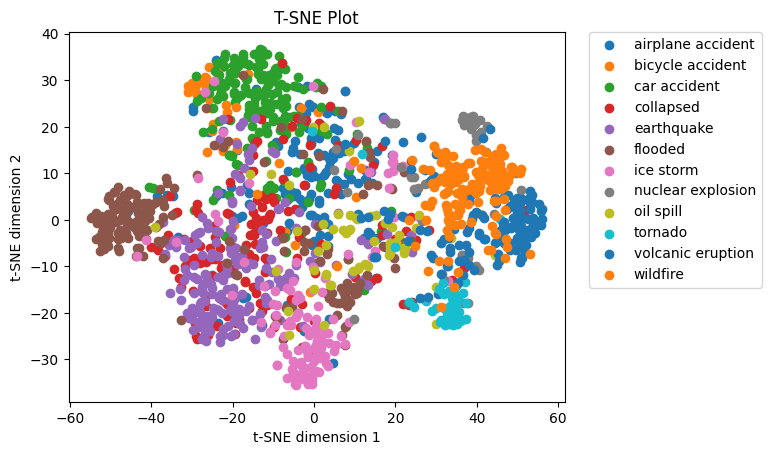

In [214]:
# set parameters for plotting
plot_all(model_name='mobilenetv2_attention', oversample=True, pretrained=False, num_folds=5)

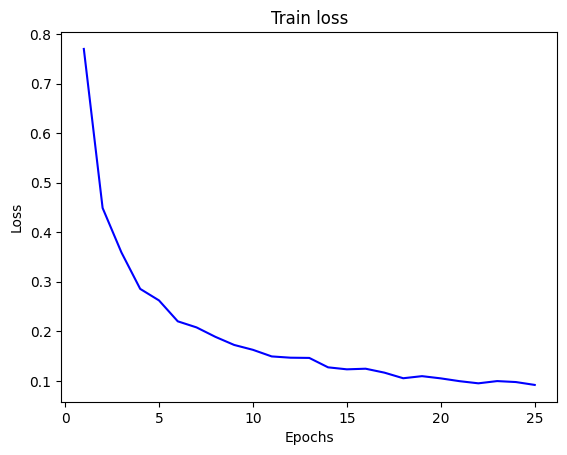

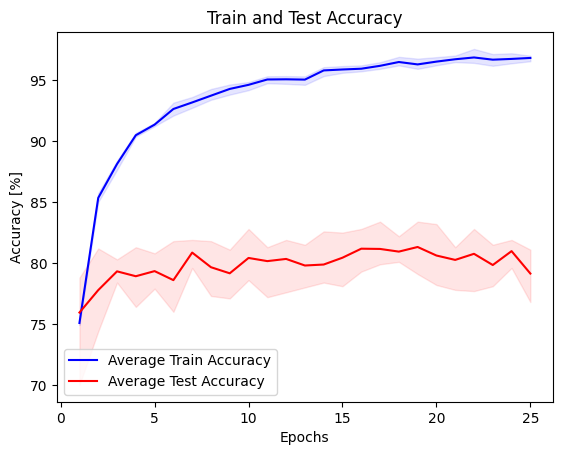

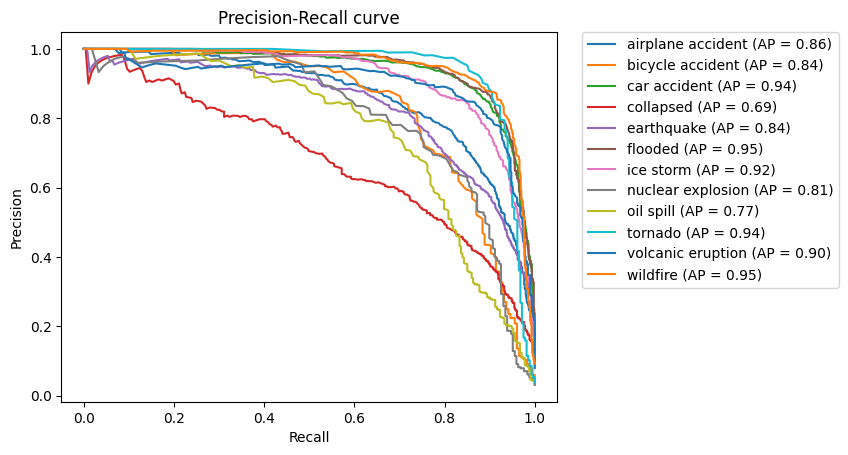

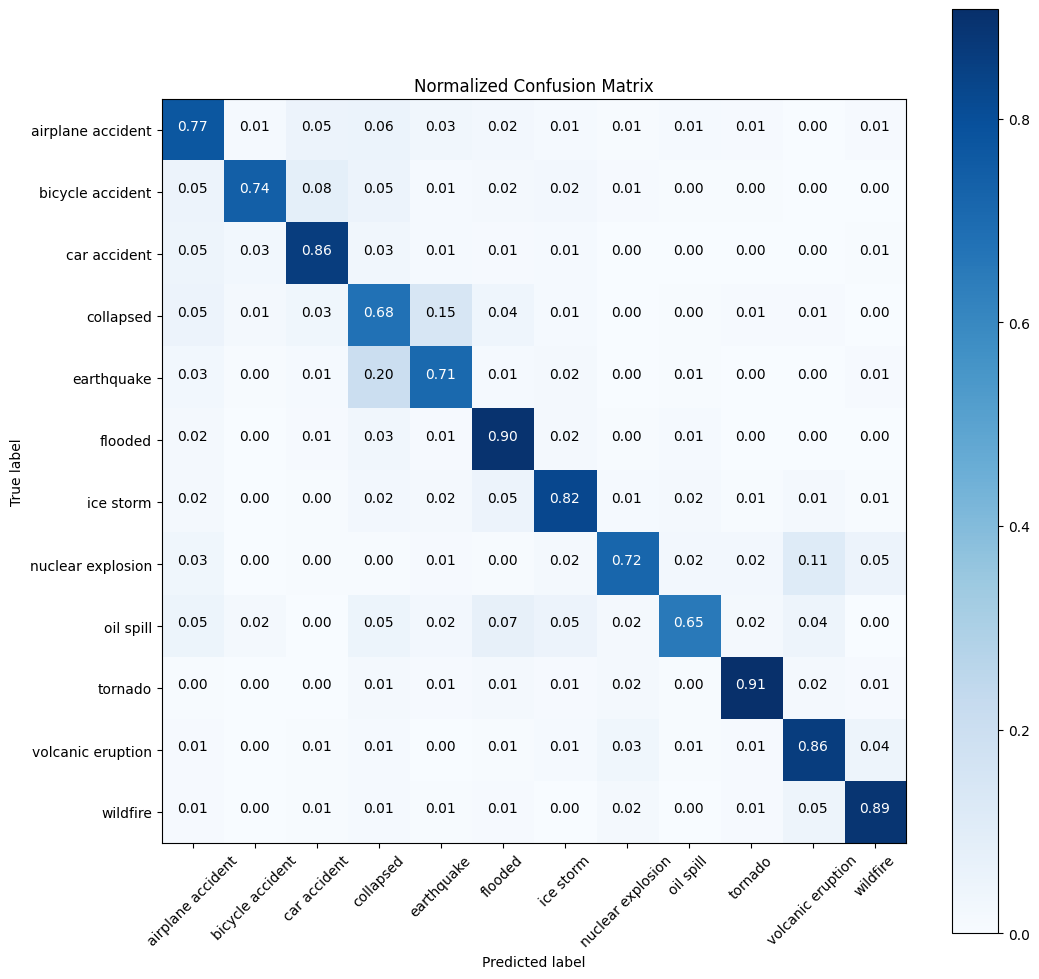

F1 score: 0.8033
Accuracy: 0.8022


C:\Users\raulv\Desktop\2A\2A-env\lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


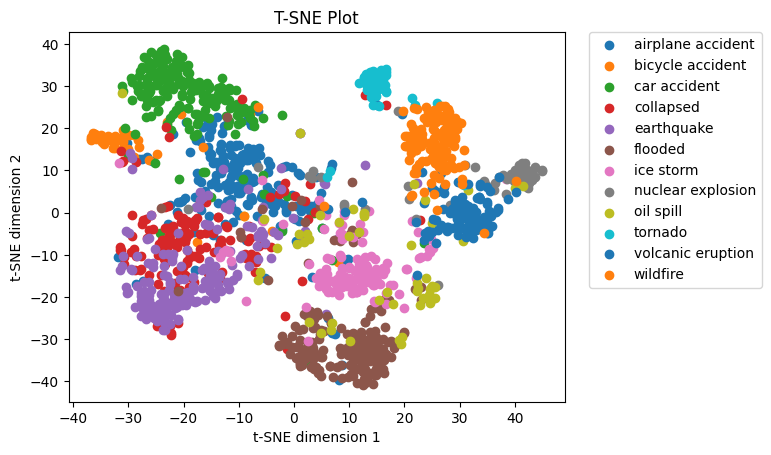

In [24]:
plot_all(model_name='mobilenetv2_attention', oversample=True, pretrained=True, num_folds=5)

## Plot saliency maps for random examples

In [202]:
sampler = torch.utils.data.SubsetRandomSampler(np.load(os.path.join('results', model_name.split('_')[0], f'{model_name}{oversample_status}{pretrained_status}', f'fold_1', 'test_indices.npy')))
subset = CustomDataset(dataset, transform=test_transform)
test_loader = DataLoader(subset, batch_size=32, sampler=sampler)

model = load_model(model_name, len(classes)).to('cuda')
model.load_state_dict(torch.load(os.path.join('results', model_name.split('_')[0], f'{model_name}{oversample_status}{pretrained_status}', f'fold_1', 'weights.pt')))

<All keys matched successfully>

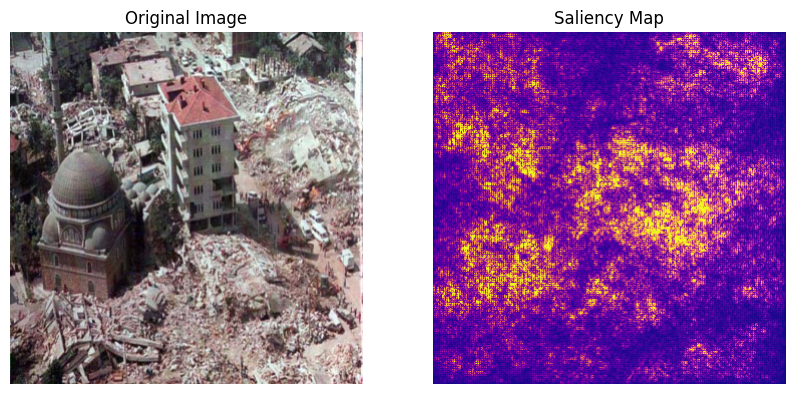

In [205]:
show_saliency_map(model, test_loader)